# Oasis Infobyte Internship

# Task 4: Email Spam Detection with Machine Learning

## Internship Domain
**Data Science**

---

## Project Overview

Email spam detection is one of the most common applications of Natural Language Processing (NLP) and Machine Learning. Spam messages often contain advertisements, phishing attempts, scams, or malicious content, while legitimate messages (ham) contain useful communication.

In this project, we build a machine learning model that automatically classifies messages as **Spam** or **Ham (Not Spam)**. The project includes text preprocessing, feature extraction using TF-IDF Vectorization, training multiple classification algorithms, and evaluating their performance using standard classification metrics.

---

## Objectives

- Load and inspect the spam dataset
- Clean and preprocess text data
- Convert text into numerical features using TF-IDF
- Train multiple machine learning classifiers
- Evaluate model performance
- Compare classifiers
- Predict whether a message is Spam or Ham

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- NLTK
- Google Colab (Jupyter Notebook)

---

## Dataset

**spam.csv**

---

## Author

**Anirban Garai**

Oasis Infobyte Internship

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Importing Libraries

The following libraries are required for this project.

### NumPy
Used for numerical computations.

### Pandas
Used for loading and manipulating the dataset.

### Matplotlib
Used for creating visualizations.

### Seaborn
Used for attractive statistical plots.

Additional NLP libraries will be imported later during the text preprocessing stage.

In [2]:
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# Loading the Dataset

The dataset contains SMS messages labeled as either:

- **Ham** (Legitimate Message)
- **Spam** (Unwanted or Promotional Message)

These messages will be used to train a machine learning classifier capable of distinguishing spam from legitimate messages.

In [3]:
# Load Dataset

df = pd.read_csv("spam.csv", encoding="latin-1")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


# Display Dataset

Let's display the first few rows of the dataset to understand its structure.

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# Dataset Information

The `info()` function provides useful information such as:

- Number of rows and columns
- Data types
- Missing values
- Memory usage

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


# Shape of Dataset

The shape tells us how many observations and features are available for analysis.

In [6]:
print("Rows :", df.shape[0])

print("Columns :", df.shape[1])

Rows : 5572
Columns : 5


# Column Names

Let's inspect the available columns in the dataset.

In [7]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

# Renaming Columns

The dataset uses generic column names such as **v1** and **v2**.

For better readability:

- **v1 → Label**
- **v2 → Message**

In [8]:
df.rename(columns={
    "v1":"Label",
    "v2":"Message"
}, inplace=True)

df.head()

,Label,Message,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# Removing Unnecessary Columns

The dataset contains three unnamed columns that do not contribute to spam detection.

These columns will be removed.

In [9]:
df.drop(
    columns=[
        "Unnamed: 2",
        "Unnamed: 3",
        "Unnamed: 4"
    ],
    inplace=True
)

df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Updated Dataset Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Label    5572 non-null   object
 1   Message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


# Data Types

Let's verify the data types after preprocessing.

In [11]:
df.dtypes

,0
Label,object
Message,object


# Display Last 10 Records

Viewing the last few rows helps verify that the dataset has been loaded correctly.

In [12]:
df.tail(10)

,Label,Message
5562,ham,Ok lor... Sony ericsson salesman... I ask shuh...
5563,ham,Ard 6 like dat lor.
5564,ham,Why don't you wait 'til at least wednesday to ...
5565,ham,Huh y lei...
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


# Sample Records

Displaying random samples provides another quick look at the dataset.

In [13]:
df.sample(10)

,Label,Message
3889,spam,Double Mins & 1000 txts on Orange tariffs. Lat...
356,spam,Congratulations ur awarded 500 of CD vouchers ...
2387,ham,Also where's the piece
132,ham,First answer my question.
5424,ham,U horrible gal... U knew dat i was going out w...
3758,ham,"GOD ASKED, \What is forgiveness?\"" A little ch..."
3520,ham,Hey... are you going to quit soon? Xuhui and i...
4094,ham,I ain't answerin no phone at what is actually ...
3997,spam,We tried to call you re your reply to our sms ...
2506,ham,Who u talking about?


# Basic Dataset Overview

Let's inspect the dimensions of the dataset and count the number of unique values in each column.

In [14]:
print("Dataset Shape :", df.shape)

print("\nUnique Values\n")

for col in df.columns:
    print(col, ":", df[col].nunique())

Dataset Shape : (5572, 2)

Unique Values

Label : 2
Message : 5169


# Target Variable

The target variable for this classification problem is:

**Label**

Where:

- **Ham** → Legitimate Email/SMS
- **Spam** → Unwanted or Promotional Message

The model will learn to classify new messages into one of these two categories.

In [15]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


# Dataset Overview

From the initial inspection, we understand:

- The dataset contains labeled text messages.
- The target variable is **Label**.
- The remaining feature is the message text.
- The dataset is ready for cleaning and NLP preprocessing.

---

# Data Cleaning

Before training a machine learning model, we must clean and preprocess the dataset.

The following steps will be performed:

- Check missing values
- Check duplicate records
- Remove duplicate records (if any)
- Verify the class distribution

In [16]:
# Checking Missing Values

df.isnull().sum()

,0
Label,0
Message,0


# Missing Values Analysis

Let's visualize missing values using a heatmap.

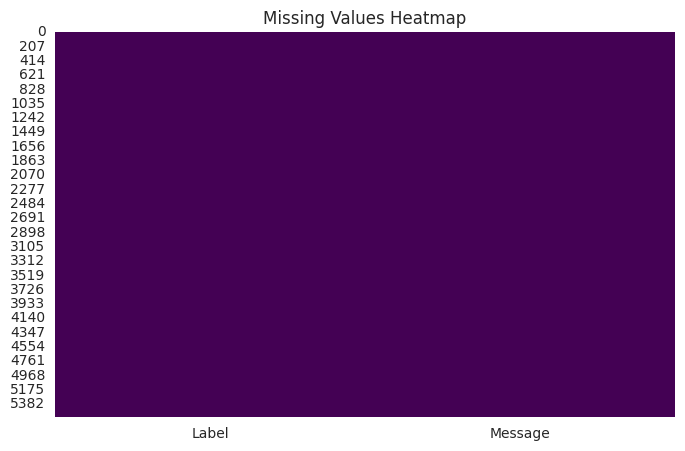

In [17]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

### Observation

- The dataset contains no significant missing values.
- Therefore, no missing value treatment is required.

# Duplicate Records

Duplicate messages may reduce the effectiveness of the classifier.

Let's check whether duplicate records exist.

In [18]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 403


# Removing Duplicate Records

In [19]:
df = df.drop_duplicates()

print("New Shape :", df.shape)

New Shape : (5169, 2)


# Class Distribution

Before training the model, let's examine the distribution of Spam and Ham messages.

In [20]:
df["Label"].value_counts()

,count
Label,
ham,4516
spam,653


# Visualizing Class Distribution

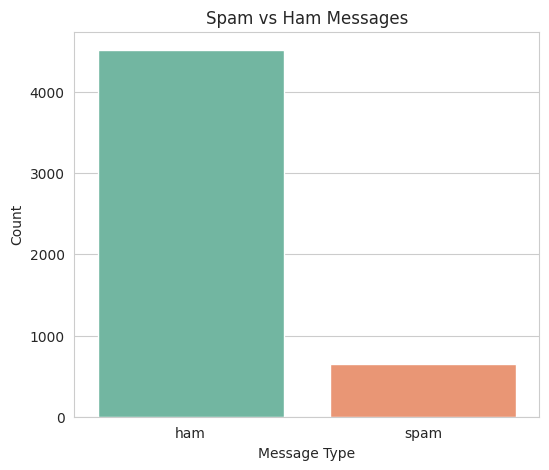

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Label",
    palette="Set2"
)

plt.title("Spam vs Ham Messages")

plt.xlabel("Message Type")

plt.ylabel("Count")

plt.show()

### Observation

- Ham messages are more frequent than spam messages.
- The dataset is slightly imbalanced, which is common in spam detection datasets.

---

# Natural Language Processing (NLP)

Machine learning algorithms cannot directly understand raw text.

Therefore, the text must be cleaned and converted into a suitable format before feature extraction.

## Importing NLP Libraries

In [22]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Initializing Stopwords and Stemmer

In [23]:
stop_words = set(stopwords.words("english"))

stemmer = PorterStemmer()

# Text Preprocessing

Each message will undergo the following preprocessing steps:

- Convert to lowercase
- Remove punctuation
- Remove numbers
- Remove special characters
- Remove stopwords
- Apply stemming

In [24]:
def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords & stemming
    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

# Creating Cleaned Messages

Now we apply the preprocessing function to every message in the dataset.

In [25]:
df["Clean_Message"] = df["Message"].apply(preprocess_text)

df.head()

,Label,Message,Clean_Message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


# Comparing Original and Cleaned Messages

In [26]:
df[["Message","Clean_Message"]].head(10)

,Message,Clean_Message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl week word back id like fun st...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request mell mell oru minnaminungint nurun...
8,WINNER!! As a valued network customer you have...,winner valu network custom select receivea å£ ...
9,Had your mobile 11 months or more? U R entitle...,mobil month u r entitl updat latest colour mob...


### Observation

The cleaned messages are:

- Converted to lowercase
- Free from punctuation
- Free from numbers
- Free from stopwords
- Reduced to root words using stemming

These cleaned messages are more suitable for machine learning.

# Message Length Analysis

Let's compare the length of messages before preprocessing.

In [27]:
df["Message_Length"] = df["Message"].apply(len)

df["Message_Length"].describe()

,Message_Length
count,5169.000000
mean,78.977945
std,58.236293
min,2.000000
25%,36.000000
50%,60.000000
75%,117.000000
max,910.000000


# Distribution of Message Length

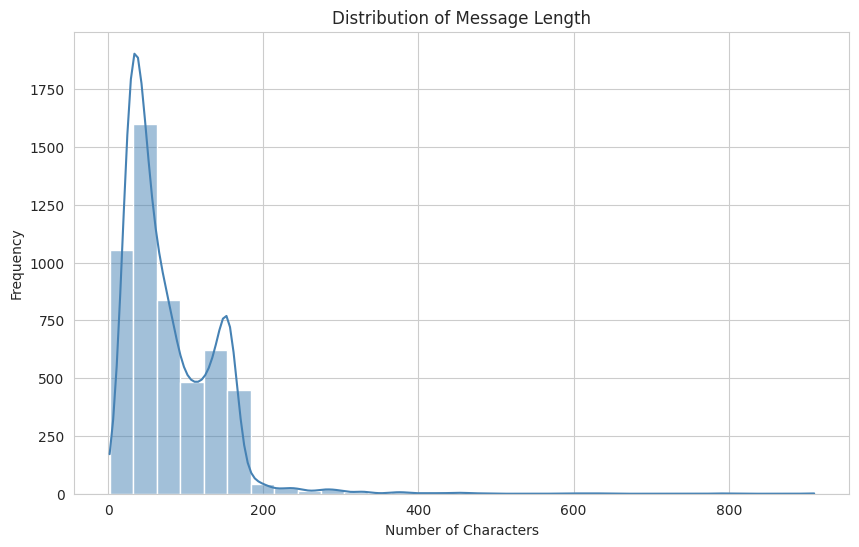

In [28]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Message_Length"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Message Length")

plt.xlabel("Number of Characters")

plt.ylabel("Frequency")

plt.show()

### Observation

- Most messages are relatively short.
- A small number of messages are significantly longer than the average.

---

# Feature Extraction using TF-IDF Vectorizer

Machine learning algorithms cannot directly understand text.

Therefore, text messages must first be converted into numerical features.

One of the most popular techniques is **TF-IDF (Term Frequency – Inverse Document Frequency)**.

### What is TF-IDF?

TF-IDF measures how important a word is within a document compared to the entire collection of documents.

- **Term Frequency (TF):** Measures how frequently a word appears in a message.
- **Inverse Document Frequency (IDF):** Reduces the importance of words that appear very frequently across all messages.

Words that occur frequently in one message but rarely across other messages receive higher TF-IDF scores, making them more useful for classification.

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Applying TF-IDF Vectorization

In [30]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["Clean_Message"])

y = df["Label"]

print("Feature Matrix Shape :", X.shape)

Feature Matrix Shape : (5169, 7111)


# Encoding Target Variable

The target labels must be converted into numerical values.

- Ham → 0
- Spam → 1

In [31]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Classes :", encoder.classes_)

Classes : ['ham' 'spam']


# Splitting the Dataset

The dataset is divided into training and testing sets.

- Training Data : 80%
- Testing Data : 20%

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape[0])

print("Testing Samples :", X_test.shape[0])

Training Samples : 4135
Testing Samples : 1034


# Importing Machine Learning Models

Two classification algorithms will be trained:

- Multinomial Naive Bayes
- Logistic Regression

In [33]:
from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Model 1: Multinomial Naive Bayes

Multinomial Naive Bayes is widely used for text classification because it performs well with word frequency features such as TF-IDF.

In [34]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_prediction = nb_model.predict(X_test)

# Evaluating Multinomial Naive Bayes

In [35]:
nb_accuracy = accuracy_score(y_test, nb_prediction)

nb_precision = precision_score(y_test, nb_prediction)

nb_recall = recall_score(y_test, nb_prediction)

nb_f1 = f1_score(y_test, nb_prediction)

print("Accuracy :", round(nb_accuracy,3))

print("Precision :", round(nb_precision,3))

print("Recall :", round(nb_recall,3))

print("F1 Score :", round(nb_f1,3))

Accuracy : 0.961
Precision : 1.0
Recall : 0.724
F1 Score : 0.84


### Observation

Multinomial Naive Bayes is considered one of the strongest baseline models for spam detection because it efficiently handles text data.

# Confusion Matrix - Multinomial Naive Bayes

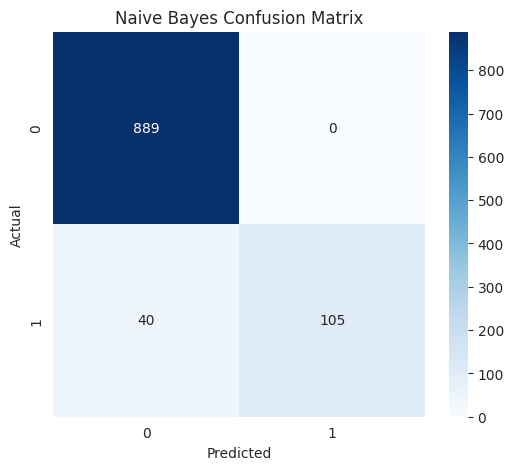

In [36]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, nb_prediction),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Classification Report - Multinomial Naive Bayes

In [37]:
print(classification_report(y_test, nb_prediction))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       1.00      0.72      0.84       145

    accuracy                           0.96      1034
   macro avg       0.98      0.86      0.91      1034
weighted avg       0.96      0.96      0.96      1034



# Model 2: Logistic Regression

Logistic Regression is another widely used algorithm for binary classification problems such as spam detection.

In [38]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_prediction = lr_model.predict(X_test)

# Evaluating Logistic Regression

In [39]:
lr_accuracy = accuracy_score(y_test, lr_prediction)

lr_precision = precision_score(y_test, lr_prediction)

lr_recall = recall_score(y_test, lr_prediction)

lr_f1 = f1_score(y_test, lr_prediction)

print("Accuracy :", round(lr_accuracy,3))

print("Precision :", round(lr_precision,3))

print("Recall :", round(lr_recall,3))

print("F1 Score :", round(lr_f1,3))

Accuracy : 0.947
Precision : 0.941
Recall : 0.662
F1 Score : 0.777


### Observation

Logistic Regression often performs competitively for binary text classification and provides an excellent comparison with Naive Bayes.

# Confusion Matrix - Logistic Regression

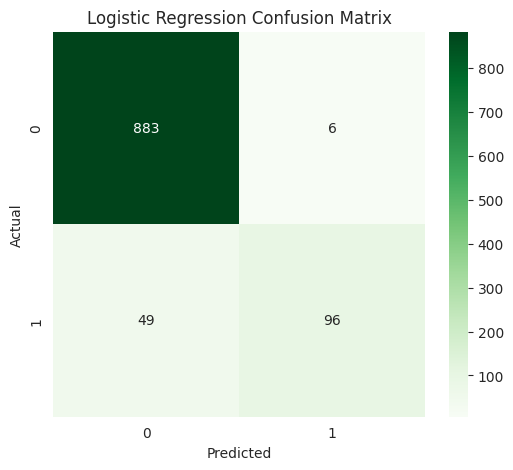

In [40]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, lr_prediction),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Classification Report - Logistic Regression

In [41]:
print(classification_report(y_test, lr_prediction))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       889
           1       0.94      0.66      0.78       145

    accuracy                           0.95      1034
   macro avg       0.94      0.83      0.87      1034
weighted avg       0.95      0.95      0.94      1034



# Model Comparison

In [42]:
comparison = pd.DataFrame({

    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],

    "Accuracy": [
        nb_accuracy,
        lr_accuracy
    ],

    "Precision": [
        nb_precision,
        lr_precision
    ],

    "Recall": [
        nb_recall,
        lr_recall
    ],

    "F1 Score": [
        nb_f1,
        lr_f1
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.961315,1.000000,0.724138,0.840000
1,Logistic Regression,0.946809,0.941176,0.662069,0.777328


### Observation

- Higher Accuracy indicates better overall prediction performance.
- Higher Precision reduces false positive classifications.
- Higher Recall reduces false negative classifications.
- Higher F1-score represents a better balance between Precision and Recall.

---

# Selecting the Best Model

After comparing the performance of both classifiers, we select the model with the highest accuracy and F1-score.

This model will be used for predicting new messages.

In [43]:
models = {
    "Multinomial Naive Bayes": nb_model,
    "Logistic Regression": lr_model
}

scores = {
    "Multinomial Naive Bayes": nb_accuracy,
    "Logistic Regression": lr_accuracy
}

best_model_name = max(scores, key=scores.get)

best_model = models[best_model_name]

print("Best Model :", best_model_name)

print("Accuracy :", round(scores[best_model_name],3))

Best Model : Multinomial Naive Bayes
Accuracy : 0.961


# Bonus: WordCloud Visualization

WordClouds help visualize the most frequently occurring words in the dataset.

Larger words indicate higher frequency.

In [44]:
from wordcloud import WordCloud

# WordCloud for Ham Messages

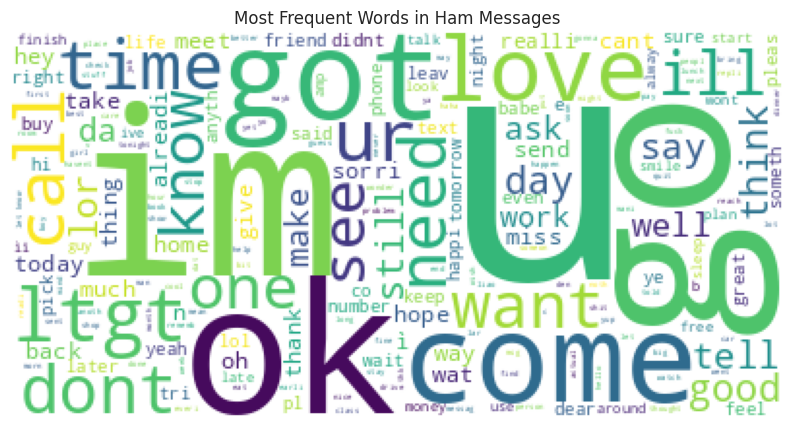

In [45]:
ham_words = " ".join(
    df[df["Label"]=="ham"]["Clean_Message"]
)

plt.figure(figsize=(10,6))

plt.imshow(
    WordCloud(
        background_color="white"
    ).generate(ham_words)
)

plt.axis("off")

plt.title("Most Frequent Words in Ham Messages")

plt.show()

### Observation

The WordCloud highlights the words most frequently used in legitimate (ham) messages.

# WordCloud for Spam Messages

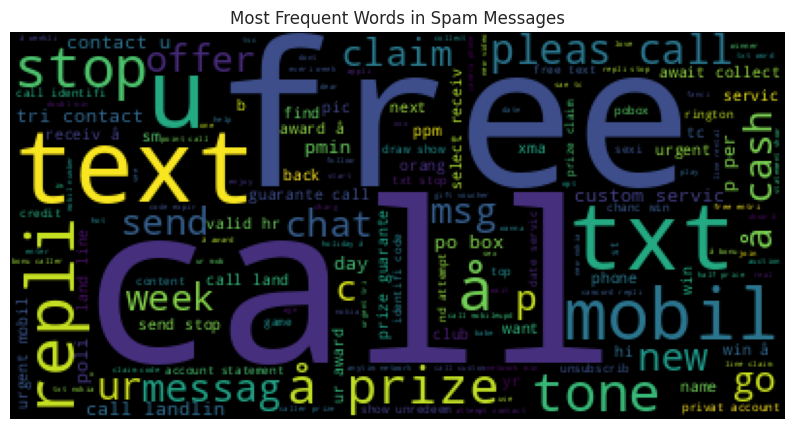

In [46]:
spam_words = " ".join(
    df[df["Label"]=="spam"]["Clean_Message"]
)

plt.figure(figsize=(10,6))

plt.imshow(
    WordCloud(
        background_color="black"
    ).generate(spam_words)
)

plt.axis("off")

plt.title("Most Frequent Words in Spam Messages")

plt.show()

### Observation

The spam WordCloud displays words commonly found in promotional, marketing, and fraudulent messages.

# Predicting a New Message

Let's classify a custom message using the best-performing model.

In [48]:
message = ["Congratulations! You have won a free iPhone. Click here to claim your prize."]

clean_message = preprocess_text(message[0])

vector = tfidf.transform([clean_message])

prediction = best_model.predict(vector)

if prediction[0] == 1:
    print("Prediction : Spam")
else:
    print("Prediction : Ham")

Prediction : Spam


# Why is Recall Important in Spam Detection?

Recall measures the proportion of actual spam messages that are correctly identified by the model.

A high recall is especially important because failing to detect spam may expose users to phishing attacks, scams, malicious links, or unwanted advertisements.

While precision minimizes false alarms, recall minimizes the number of dangerous spam messages that incorrectly pass through as legitimate emails.

Therefore, an effective spam detection system should maintain a high recall while also achieving good precision and overall accuracy.

# Key Insights

In [50]:
print("========== PROJECT INSIGHTS ==========\n")

print("Total Messages :", df.shape[0])

print("Spam Messages :", (df["Label"]=="spam").sum())

print("Ham Messages :", (df["Label"]=="ham").sum())

print("\nBest Model :", best_model_name)

print("Accuracy :", round(scores[best_model_name],3))

========== PROJECT INSIGHTS ==========

Total Messages : 5169
Spam Messages : 653
Ham Messages : 4516

Best Model : Multinomial Naive Bayes
Accuracy : 0.961


# Conclusion

In this project, an Email Spam Detection system was successfully developed using Natural Language Processing (NLP) and Machine Learning techniques.

The dataset was cleaned by removing duplicate records, followed by text preprocessing steps such as lowercase conversion, punctuation removal, stopword removal, and stemming.

The cleaned messages were converted into numerical features using the TF-IDF Vectorizer.

Two classification algorithms were trained and evaluated:

- Multinomial Naive Bayes
- Logistic Regression

The models were compared using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

The best-performing classifier was selected and used to classify new messages as either **Spam** or **Ham**.

WordCloud visualizations provided additional insights into the most frequently occurring words in spam and legitimate messages.

Overall, this project demonstrates how NLP and machine learning techniques can effectively identify spam messages and improve email security.